
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E01_gradient_descent.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Gradient descent exercises

---
These are introductory exercises in Machine learning with focus in **gradient descent** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate dataset (*)

Simulate datasets according to these rules:

- set random seed to 42
- (1000,2) samples from $X \sim \mathcal{U}(0,1)$ , i.e. 1000 rows, 2 columns. 
- 1000 samples from $\epsilon \sim \mathcal{N}(0,1)$
- $y = 3x_1 + 5x_2 + 3 + \epsilon$ , where $x_i$ is column $i$ of $X$

Finally add a column of ones for the intercept to $X$.

In [2]:
import numpy as np

np.random.seed(42)

n = 1000

X = np.random.uniform(0, 1, size=(n, 2))
eps = np.random.uniform(0, 1, size=n)

y = 3 * X[:, 0] + 5 * X[:, 1] + 3 + eps

X = np.column_stack([np.ones(n), X])

print(X)

[[1.         0.37454012 0.95071431]
 [1.         0.73199394 0.59865848]
 [1.         0.15601864 0.15599452]
 ...
 [1.         0.75137509 0.65695516]
 [1.         0.95661462 0.06895802]
 [1.         0.05705472 0.28218707]]



<details>

<summary>Hint</summary>

Use for simulating X

´´´
np.random.rand(samples, 2)
´´´

to concatenate with ones, use ```np.c_[..., ...]```

</details>

<details>

<summary>Answer</summary>

```
array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

```

</details>

---

## 1. Gradient descent - learning rate (*)

Use gradient descent to calculate $\vec{\theta} = (\theta_0, \theta_1, \theta_2)^T$ 

&nbsp; a) Use $\eta = 0.1$ and calculate $\vec{\theta}$ for each fifth epoch from 1 to 500. So the procedure is as follows:
- calculate $\vec{\theta}$ for epochs = 1
- calculate $\vec{\theta}$ for epochs = 6
- ...
- calculate $\vec{\theta}$ for epochs = 496

Plot these $\vec{\theta}$ values against epochs. (*)

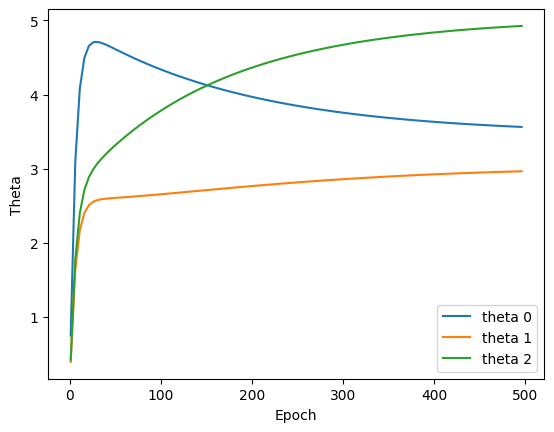

In [6]:
import matplotlib.pyplot as plt

n, d = X.shape
theta = np.zeros(d)

eta = 0.1

epochs_a = []
theta_hist_a = []

for epoch in range(1, 501):
    grad = (1/n) * X.T @ (X @ theta - y)
    theta = theta - eta * grad

    if (epoch -1) % 5 == 0:
        epochs_a.append(epoch)
        theta_hist_a.append(theta.copy())

theta_hist_a = np.array(theta_hist_a)
epochs_a = np.array(epochs_a)


plt.plot(epochs_a, theta_hist_a[:, 0], label="theta 0")
plt.plot(epochs_a, theta_hist_a[:, 1], label="theta 1")
plt.plot(epochs_a, theta_hist_a[:, 2], label="theta 2")
plt.xlabel("Epoch")
plt.ylabel("Theta")
plt.legend()
plt.show()


&nbsp; b) Do the same as for a) but with learning rate $\eta = 0.01$, 5000 epochs and for each 20th epoch. What do you notice when changing the learning rate? (*)


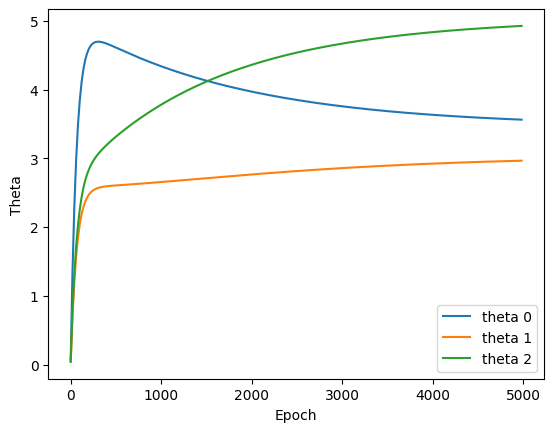

In [5]:
theta = np.zeros(d)
eta = 0.01

theta_hist_b = []
epochs_b =[]

for epoch in range(1, 5001):
    grad = (1/n) * X.T @ (X @ theta - y)
    theta = theta - eta * grad

    if (epoch -1) % 20 == 0:
        epochs_b.append(epoch)
        theta_hist_b.append(theta.copy())

theta_hist_b = np.array(theta_hist_b)
epochs_b = np.array(epochs_b)

plt.plot(epochs_b, theta_hist_b[:, 0], label="theta 0")
plt.plot(epochs_b, theta_hist_b[:, 1], label="theta 1")
plt.plot(epochs_b, theta_hist_b[:, 2], label="theta 2")
plt.xlabel("Epoch")
plt.ylabel("Theta")
plt.legend()
plt.show()



&nbsp; c) Experiment with larger and smaller $\eta$ and see what happens.



<details>

<summary>Answer</summary>

a) 

<img src="../assets/grad_desc_converg.png" height="200"/>

b) 

<img src="../assets/grad_desc_converg_001.png" height="200"/>

</details>

---

## 2. Stochastic Gradient Descent - learning rate (**)

Repeat task 1 but using stochastic gradient descent instead. Also adjust number of epochs to see if you can find convergence. What kind of conclusions can you draw from your experiments. (**)

---

## 3. Mini Batch Gradient Descent (**)

Now try different sizes of mini-batches and make some exploratory plots to see convergence. Also you can make comparison to the other algorithms by using same $\eta$ and same amount of epochs to see how they differ from each other in terms of convergence. (**)

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---